In [1]:
# Path
import os, sys
os.chdir('/home/zwang34/IBL/iblfm_exp/IBL_foundation_model')
sys.path.append('./src')

In [2]:
# Lib
from datasets import load_dataset, concatenate_datasets
import numpy as np
from accelerate import Accelerator
from loader.make_loader import make_loader
from utils.eval_utils import bits_per_spike
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import argparse
import torch
import torch.nn as nn
from src.utils.utils import move_batch_to_device, metrics_list, plot_gt_pred, plot_neurons_r2
import wandb
from tqdm import tqdm
from cebra import CEBRA
import cebra.models

/home/zwang34/miniconda3/envs/cebra/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Args
eid = '746d1902-fa59-4cab-b0aa-013be36060d5'


In [13]:
# Load Data
dataset = load_dataset(f'neurofm123/{eid}_aligned', cache_dir='/expanse/lustre/scratch/zwang34/temp_project/iTransformer/checkpoints/datasets_cache')
# dataset = load_dataset(f'neurofm123/{eid}_aligned', cache_dir='/expanse/lustre/scratch/zwang34/temp_project/iTransformer/checkpoints/datasets_cache', download_mode='force_redownload')
train_dataset = dataset['train']

try:
    bin_size = train_dataset["binsize"][0]
except:
    bin_size = train_dataset["bin_size"][0]

n_neurons = len(train_dataset[0]['cluster_uuids'])
print(f'n neurons: {n_neurons}')

# only use train data first
train_dataloader = make_loader(
    train_dataset,
    target='whisker-motion-energy',
    load_meta=True,
    batch_size=10000,
    pad_to_right=True,
    pad_value=-1,
    bin_size=0.02,
    max_time_length=100,
    max_space_length=n_neurons,
    dataset_name='ibl',
    shuffle=False,
)

for batch in train_dataloader:
    neural_data = batch['spikes_data'].detach().cpu().numpy()
    beh_data = batch['target'].detach().cpu().numpy()

n neurons: 1337
len(dataset): 453


In [14]:
neural_data = neural_data.reshape(-1, neural_data.shape[-1])
beh_data = beh_data.reshape(-1, 1)
print(neural_data.shape, beh_data.shape)

(45300, 1337) (45300, 1)


In [15]:
train_dataset

Dataset({
    features: ['spikes_sparse_data', 'spikes_sparse_indices', 'spikes_sparse_indptr', 'spikes_sparse_shape', 'choice', 'reward', 'block', 'whisker-motion-energy', 'binsize', 'interval_len', 'eid', 'sampling_freq', 'cluster_regions', 'cluster_channels', 'cluster_depths', 'good_clusters', 'cluster_uuids', 'cluster_qc', 'start_times', 'end_times'],
    num_rows: 453
})

# CEBRA

In [16]:
import cebra.models
print(cebra.models.get_options('offset*', limit = 10))

['offset10-model', 'offset10-model-mse', 'offset5-model', 'offset1-model-mse', 'offset1-model', 'offset1-model-v2', 'offset1-model-v3', 'offset1-model-v4', 'offset1-model-v5', 'offset40-model-4x-subsample']


In [17]:
cebra_model = CEBRA(
    model_architecture = "offset10-model",
    conditional='time',
    batch_size = 2048,
    temperature_mode="auto",
    learning_rate = 0.001,
    max_iterations = 10000,
    time_offsets = 10,
    output_dimension = 8,
    device = "cuda_if_available",
    verbose = True
)

cebra_model.fit(neural_data)

pos: -9.8527 neg:  12.0960 total:  2.2433 temperature:  0.1000: 100%|██████████| 10000/10000 [04:33<00:00, 36.53it/s]


CEBRA(batch_size=2048, conditional='time', learning_rate=0.001,
      model_architecture='offset10-model', temperature_mode='auto',
      time_offsets=10, verbose=True)

<Axes: xlabel='Steps', ylabel='InfoNCE Loss'>

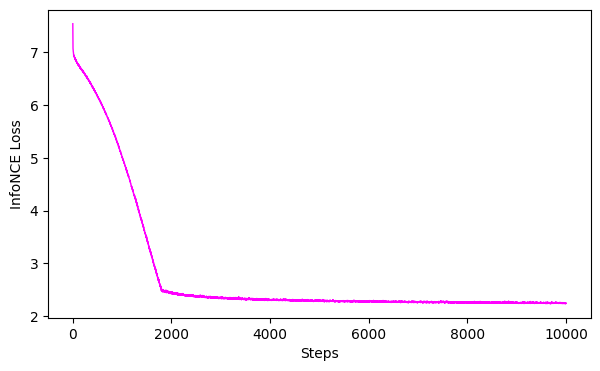

In [18]:
cebra.plot_loss(cebra_model)

In [19]:
cebra_emb = cebra_model.transform(neural_data)
print(neural_data.shape, cebra_emb.shape, beh_data.shape)

(45300, 1337) (45300, 8) (45300, 1)


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_cebra_emb_3d(cebra_emb, color_array, dim1, dim2, dim3, 
                      title="CEBRA Embeddings 3D Scatter Plot", 
                      cmap='viridis', vmin=None, vmax=None, s=0.1):
    # 确保输入的维度是有效的
    max_dim = cebra_emb.shape[1] - 1
    if max(dim1, dim2, dim3) > max_dim:
        raise ValueError(f"Dimension index out of range. Max dimension is {max_dim}")
    
    # 确保颜色数组的长度与cebra_emb的行数相匹配
    if len(color_array) != cebra_emb.shape[0]:
        raise ValueError("Length of color_array must match the number of points in cebra_emb")

    # 创建图形和3D轴
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 获取选定维度的数据
    x = cebra_emb[:, dim1]
    y = cebra_emb[:, dim2]
    z = cebra_emb[:, dim3]

    # 创建散点图，使用提供的颜色数组和指定的颜色范围
    scatter = ax.scatter(x, y, z, c=color_array, cmap=cmap, vmin=vmin, vmax=vmax, s=s)

    # 设置轴标签
    ax.set_xlabel(f'Dimension {dim1}')
    ax.set_ylabel(f'Dimension {dim2}')
    ax.set_zlabel(f'Dimension {dim3}')

    # 设置标题
    ax.set_title(title)

    # 添加颜色条，使用相同的vmin和vmax
    cbar = plt.colorbar(scatter, label='Color Value')
    if vmin is not None and vmax is not None:
        cbar.mappable.set_clim(vmin, vmax)

    # 显示图形
    plt.show()

# 使用示例
# cebra_emb = np.random.rand(1000, 50)  # 创建一个示例数组
# color_array = np.random.rand(1000)  # 创建一个示例颜色数组
# plot_cebra_emb_3d(cebra_emb, color_array, 1, 2, 3, vmin=0.2, vmax=0.8)

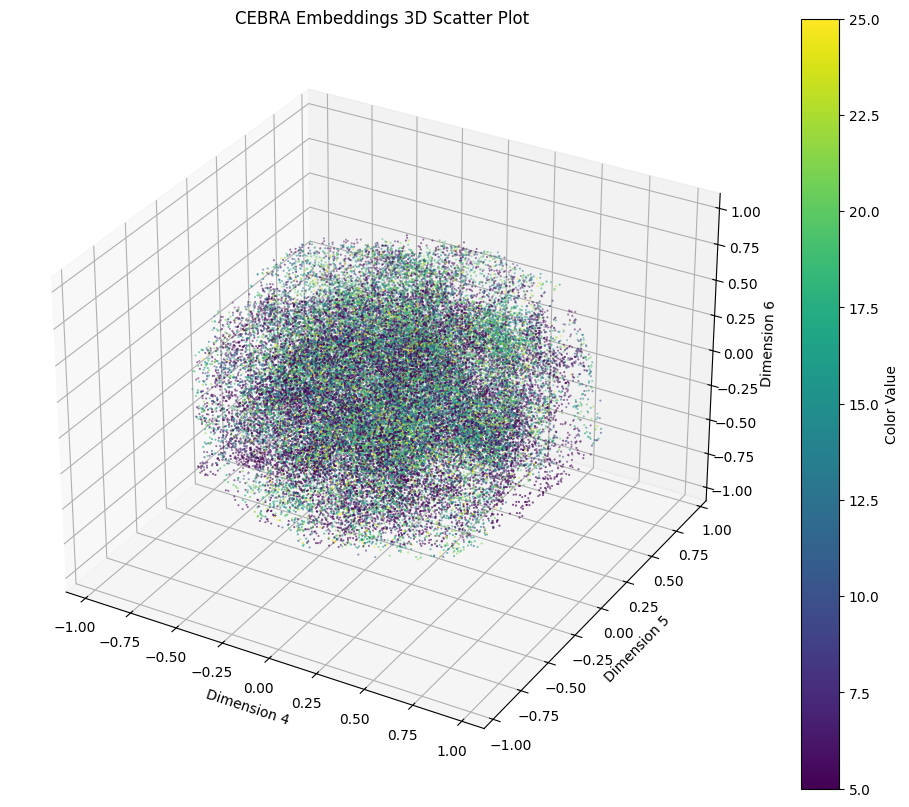

In [26]:
plot_cebra_emb_3d(cebra_emb, beh_data.flat, 4, 5, 6, vmin=5, vmax=25, cmap='viridis', s=0.2)

(array([1.000e+00, 1.000e+00, 1.000e+00, 2.600e+01, 7.257e+03, 4.447e+03,
        2.517e+03, 1.557e+03, 9.970e+02, 6.910e+02, 6.070e+02, 5.430e+02,
        5.750e+02, 6.470e+02, 7.350e+02, 9.110e+02, 1.043e+03, 1.239e+03,
        1.403e+03, 1.546e+03, 1.671e+03, 1.799e+03, 1.866e+03, 1.851e+03,
        1.969e+03, 1.991e+03, 1.975e+03, 1.763e+03, 1.465e+03, 9.800e+02,
        5.490e+02, 2.850e+02, 1.600e+02, 8.500e+01, 5.400e+01, 3.000e+01,
        2.600e+01, 1.100e+01, 9.000e+00, 3.000e+00, 2.000e+00, 6.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 2.000e+00]),
 array([-2.98072624, -2.12027955, -1.25983274, -0.39938602,  0.4610607 ,
         1.32150745,  2.18195415,  3.04240084,  3.90284777,  4.76329422,
         5.62374115,  6.48418808,  7.34463453,  8.20508099,  9.06552792,
         9.92597485, 10.78642178, 11.64686871, 12.50731468, 13.36776161,
        14.22820854, 15.08865547, 15.9491024 , 16.80954933, 17.66999626,
        18.

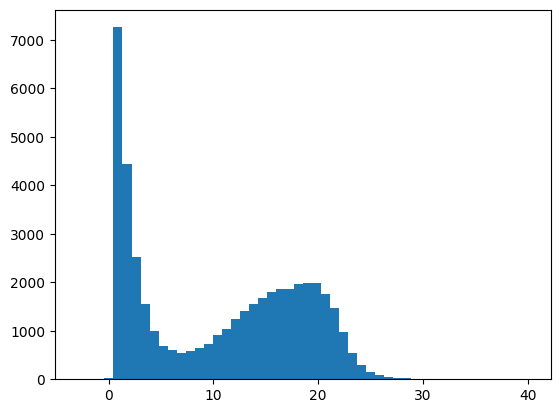

In [24]:
plt.hist(beh_data, bins=50)